# Régression

Au dernier module, on a abordé **classification** : c'est un type de tâche qui vise à prédire à quelle classe appartient une certaine observation, parmi un ensemble de classes prédéfinies.

Est-ce qu'on a une photo de chat, une photo de chien ou une photo de vache?

&nbsp;

On a parlé d'un seul algorithme de classification à date, KNN (K plus proches voisins), mais gardez en tête qu'il en existe plusieurs autres.

&nbsp;

La **régression** est un autre type de tâche, où on vise plutôt à prédire une valeur **quantitative**.

Quelle température fera-t-il demain? 5°C? 6°C? 5.1°C? 5.005°C?

Comme pour la classification, plusieurs algorithmes différents permettent de faire de la régression. On va en regarder quelques uns.

&nbsp;

En classification, on a parlé de l'**exactitude** (accuracy) pour évaluer la qualité de nos prédictions. Le calcul de l'exactitude considère qu'on a soit des bonnes réponses (prédire la bonne classe), soit des erreurs (peu importe la classe prédite, si ce n'est pas la bonne c'est une erreur).

En régression, cette métrique ne fait pas de sens. Quand on prédit une valeur quantitative, on peut être **plus ou moins loin de la bonne réponse**. Ça va changer la façon dont on évalue la qualité de notre algorithme.

Dire qu'un chat est un chien est autant une erreur que de dire qu'une chèvre est une vache.

Si une maison vaut `800 000$`, prédire qu'elle en vaut `850 000$` est une meilleure réponse que de prédire `2.50$`.

&nbsp;

La forme la plus simple d'une régression serait de prédire une valeur numérique (ex.: des degrés, des cm, des dollars, ...), mais la régression peut être utilisée pour des choses plus complexes.



In [1]:
#@title Importation
import pandas as pd
import numpy as np
import plotly.express as px

## KNN pour la régression

On a utilisé l'algorithme KNN pour de la classification, en faisant :

1. Trouve les K plus proches voisins de l'observation
2. Prédit la classe majoritaire parmi les K

&nbsp;

On peut facilement transformer l'algorithme KNN pour prédire des valeurs quantitatives.

&nbsp;

On a utilisé le jeu de données des *iris* pour faire de la classification, en prédisant l'espèce de plante à partir de ses dimensions.

Si on cherchait plutôt à prédire la *longueur des pétales*  à partir d'une largeur connue, on aurait une tâche de régression.

Avec KNN, plutôt que de prédire la classe majoritaire, on pourrait prédire **la *moyenne* des dimensions des K voisins**.

## Exercice

Testons ça. Voici le jeu de données, et un rappel de ce dont a l'air la relation entre *petal_width* et *petal_length* quand on la dessine avec un nuage de points :

In [2]:
#@title Lecture du jeu de données et visualisation des dimensions des pétales

# Jeu de données un peu plus simple, on ne referra pas les étapes de supprimer les lignes vides/colonnes inutiles
iris = pd.read_csv("https://raw.githubusercontent.com/316k/misc-data/master/iris.csv")
px.scatter(iris, x="petal_width", y="petal_length", range_x=[0, 4], range_y=[0,10])

En regardant le graphique ci-haut, à l'oeil on voit à peu près :

petal_width | petal_length
--- | ---
1cm | ≈3.5cm
1.5cm | ≈4.5cm
2cm | ≈5.5cm

&nbsp;

**La relation semble être :**

- Si on augmente `petal_width` de `+0.5cm`, `petal_length` augmente d'environ `1cm`.
- Si on augmente `petal_width` de `+1cm`, `petal_length` augmente d'environ `2cm`.

**QUESTION**

On pourrait utiliser cette règle pour estimer des points qu'on ne connaît pas :

- Si `petal_width=4cm`, à combien pourriez-vous estimer `petal_length`?
- Si `petal_width=0.8cm`, à combien pourriez-vous estimer `petal_length`?

**RÉPONSE**

A) Si on a `petal_width=4cm`, on pourrait estimer `petal_length` avec :

Δ | petal_width | Δ | petal_length
--- | --- | --- | ---
_  | 2cm | _ | ≈5.5cm
+0.5cm | 2.5cm | +1cm | 6.5cm
+0.5cm | 3cm | +1cm | 7.5cm
+0.5cm | 3.5cm | +1cm | 8.5cm
+0.5cm | 4cm | +1cm | 9.5cm

Donc `petal_width = 4cm` correspondrait à `petal_length =` **9.5cm**

&nbsp;

B) On pourrait repartir de l'estimation à `petal_width=1cm` et soustraire 0.2cm

Δ | petal_width | Δ | petal_length
--- | --- | --- | ---
_  | 1cm | _ | ≈3.5cm
-0.2cm | 0.8cm | -?cm | ???


On peut faire une petite règle de trois pour avoir le ratio si on soustrait 0.2cm :

$$\frac{+0.5  \text{petal width}}{+1 \text{petal length}} = \frac{-0.2  \text{petal width}}{? \text{ petal length}} $$

$\implies -0.1 \text{petal length}$

Donc `petal_width = 0.8cm` correspondrait à 3.5cm - 0.1cm = `petal_length =` **3.4cm**

## Entraîner un modèle KNN pour la régression

Plutôt que d'utiliser `KNeighborsClassifier`, qui ferait  un vote majoritaire, on utilise **`KNeighborsRegressor`**.

In [3]:
# Importation de l'algorithme KNeighborsRegressor (KNN pour la régression)
from sklearn.neighbors import KNeighborsRegressor

# Séparation du jeu de données en 2/3 entraînement - 1/3 test
iris_melange = iris.sample(frac=1, random_state=138)
iris_entrainement = iris_melange.iloc[:2*len(iris)//3]
iris_test = iris_melange.iloc[2*len(iris)//3:]

# Création du modèle KNeighborsRegressor, avec 5 voisins
# Sensiblement similaire à ce qu'on avait fait pour le KNeighborsClassifier
modele = KNeighborsRegressor(5)

# Données d'entraînement:
# X=la colonne `petal_width` et
# y=la colonne `petal_length`
# Notez le [[...]] ici : on veut que le X_entrainement soit un __DataFrame___, et pas une série
X_entrainement = iris_entrainement[['petal_width']]
y_entrainement = iris_entrainement['petal_length']

X_test = iris_test[['petal_width']]
y_test = iris_test['petal_length']


modele.fit(X_entrainement, y_entrainement)

print('Entraînement terminé')

Entraînement terminé


On peut utiliser ce modèle et voir ce qu'il prédit pour les trois exemples de `petal_width` nommés plus haut :

In [4]:
X_petal_width_interessantes = pd.DataFrame([
# petal_width
  [1],
  [1.5],
  [2],
  [0.8],
  [4],
], columns=['petal_width'])

y_petal_length_attendues = pd.DataFrame([
# petal_length (valeur approximative attendue, selon les réponses plus haut)
  [3.5],
  [4.5],
  [5.5],
  [3.4],
  [9.5],
], columns=['petal_length'])

y_petal_length_predits = modele.predict(X_petal_width_interessantes)

for i in range(len(y_petal_length_attendues)):
  petal_width = X_petal_width_interessantes.petal_width.loc[i]
  petal_length_predit = round(y_petal_length_predits[i], 2)
  petal_length_attendu = y_petal_length_attendues.petal_length.loc[i]

  print("Si petal_width = ", petal_width, "cm,",
        " KNN prédit que petal_length = ", petal_length_predit, "cm",
        " (valeur estimée à la main: ", petal_length_attendu, "cm)",
        sep='')

Si petal_width = 1.0cm, KNN prédit que petal_length = 3.46cm (valeur estimée à la main: 3.5cm)
Si petal_width = 1.5cm, KNN prédit que petal_length = 4.66cm (valeur estimée à la main: 4.5cm)
Si petal_width = 2.0cm, KNN prédit que petal_length = 5.62cm (valeur estimée à la main: 5.5cm)
Si petal_width = 0.8cm, KNN prédit que petal_length = 3.46cm (valeur estimée à la main: 3.4cm)
Si petal_width = 4.0cm, KNN prédit que petal_length = 5.68cm (valeur estimée à la main: 9.5cm)


Notez ici quelque chose d'un peu étrange : pour les deux tailles qui n'avaient pas d'exemples (0.8cm et 4.0cm), les données prédites sont loin de ce qu'on avait estimé avec la petite règle plus haut...

&nbsp;

On peut essayer de comprendre ce qui se passe ici avec un graphique : chaque prédiction faite par KNN (en rouge) vs chaque plante du jeu de données (entraînement en bleu et test en vert).

En rose, on voit les 5 points qu'on a estimés à la main plus haut :

In [5]:
# On se sert de notre KNN pour prédire les petal_length sur toutes les valeurs
# de petal_width entre 0.1cm et 4.5cm
petal_width = np.linspace(0.1, 4.5, 1000).reshape((1000, 1))
petal_width = pd.DataFrame(petal_width, columns=['petal_width'])

predicted_petal_length = modele.predict(petal_width)
predicted_petal_length = pd.DataFrame(predicted_petal_length, columns=['predicted_petal_length'])

df = pd.concat([
    petal_width,
    predicted_petal_length
], axis='columns')

# Graphique des vrais points (bleu + vert)
verite_entrainement = px.scatter(iris_entrainement, x="petal_width", y="petal_length", range_x=[0, 4], range_y=[0,8], color_discrete_sequence=['blue'])
verite_test = px.scatter(iris_test, x="petal_width", y="petal_length", range_x=[0, 4], range_y=[0,8], color_discrete_sequence=['green'])

# 5 points intéressants (rose)
points_a_predire = np.array([1, 1.5, 2, 0.8, 4])
predictions_quelques_points = modele.predict(pd.DataFrame({'petal_width': points_a_predire}))
points_interessants = pd.DataFrame({"x": points_a_predire, "y": predictions_quelques_points, "s": [10] * len(points_a_predire) })
points_interessants = px.scatter(points_interessants, x="x", y="y", color_discrete_sequence=["hotpink"], size="s")


# Points prédits par notre KNN (rouge)
predicteur = px.scatter(df, x='petal_width', y='predicted_petal_length', range_x=[0, 4], range_y=[0,8], color_discrete_sequence=['red'])

# Graphique qui combine tout ça
from plotly.graph_objects import Figure
fig = Figure(data=verite_entrainement.data + verite_test.data + predicteur.data + points_interessants.data)
fig.update_layout(
    title="Données d'entraînement et de test (bleu, vert) vs Prédictions possibles pour notre KNN (rouge), points d'intérêt en rose",
    xaxis=dict(title="petal_width"),
    yaxis=dict(title="petal_length"),
)
display(fig)

On voit ici que KNN a un comportement un peu bizarre :

- La valeur prédite est **la même pour `petal_width=0.8cm` et pour `1cm`**. On voit bien les plateaux en rouge: changer légèrement `petal_width` n'a souvent aucun impact, car les voisins les plus proches n'ont pas changé.
- La valeur prédite est **la même pour `2cm` et pour 4cm`**. KNN est incapable d'extrapoler plus loin que les données connues : il n'y a ***pas de généralisation de la logique***

&nbsp;

Le problème est que KNN n'apprend pas vraiment à **généraliser**. C'est un algorithme qui **mémorise toutes les possibilités et qui essaie de toujours s'y référer**.

## "Apprentissage"

Quand on parle d'**"apprendre"**, on veut généralement dire : **découvrir une logique sous-jacente plutôt que seulement apprendre par coeur.**

KNN est un algorithme qui apprend par coeur ses données et qui s'arrête là.

&nbsp;

L'exemple le plus simple de *vrai apprentissage* qu'on pourrait avoir serait :

> Trouver une droite qui passe par un ensemble de points

L'équation d'une droite est :

$$y = mx + b$$

On pourrait trouver la *meilleure valeur possible* pour $m$ et la *meilleure valeur possible* pour $b$ dans ce qui correspondrait à nos données.

L'**apprentissage** consistera à trouver ces meilleures valeurs possibles pour les **paramètres** :

- $m$ (la pente de la droite)
- $b$ (l'ordonnée à l'origine)

On appelle des **paramètres** les valeurs apprises par un algorithme. Ce terme sera réutilisé plus tard.

## Approche 1 : ce que vous avez peut-être fait au secondaire

Si on connaît deux points $(x, y)$ sur la droite, on peut résoudre pour $m$ et $b$ :

$$m = \frac{y_2 - y_1}{x_2 - x_1}$$

$$b = y_1 - m x_1$$

On peut estimer ces deux points avec :

- $x_1$ = minimum de tous les $x$
- $y_1$ = minimum de tous les $y$
- $x_2$ = maximum de tous les $x$
- $y_2$ = maximum de tous les $y$

Visuellement, ça correspond à dessiner un rectangle qui englobe tous les points, puis à utiliser la diagonale du rectangle comme droite.

&nbsp;

Une fois que vous avez la formule, utilisez-la pour prédire des `petal_length`.

In [6]:
#@title Exercice 1.1
X_entrainement = iris_entrainement.petal_width # Série pour les X
y_entrainement = iris_entrainement.petal_length # Série pour les Y

x1 = ...
x2 = ...
y1 = ...
y2 = ...


# Une fois que vous avez fait ça, utilisez la formule `y = m*x + b` pour
# prédire les petal_length choses suivantes :
petal_width = np.array([3.5, 4.5, 5.5, 3, 9.5])


########

x1 = X_entrainement.min()
x2 = X_entrainement.max()

y1 = y_entrainement.min()
y2 = y_entrainement.max()

m = (y2 - y1) / (x2 - x1)
b = y1 - (m * x1)

print("m =", m)
print("b =", b)

petal_width = np.array([1, 1.5, 2, 0.75, 4])
petal_length = m * petal_width + b
print(petal_length)

m = 2.3333333333333335
b = 0.8666666666666667
[ 3.2         4.36666667  5.53333333  2.61666667 10.2       ]


Vous devriez avoir trouvé les valeurs :

- m = 2.33
- b = 0.87

### Interprétation de la formule

Si on utilise les noms des colonnes dans l'équation

$$y = mx + b$$

On obtient la règle apprise :

$$\text{ petal_length} = 2.33 * \text{ petal_width} + 0.87 \text{cm}$$

## Comparer visuellement la droite apprise avec les vraies valeurs

Une fois que vous avez trouvé vos valeurs de $m$ et $b$ avec la méthode-ci haut, affichez ce que ça donne dans le widget ci-bas pour valider.

Les points en rose correspondent aux 5

In [7]:
from ipywidgets import interact
import plotly.graph_objects as go

def dessiner_iris_avec_droite(m, b, points_a_predire):
  valeurs_x = np.linspace(0, 4.5, 100)
  valeurs_y = m * valeurs_x + b
  df = pd.DataFrame({"x": valeurs_x, "y": valeurs_y})
  plot = px.scatter(iris_entrainement, x="petal_width", y="petal_length")
  ligne = px.line(df, x="x", y="y", color_discrete_sequence=['red'])
  points_interessants = pd.DataFrame({"x": points_a_predire, "y": m * points_a_predire + b, "s": [10] * len(points_a_predire) })
  predictions = px.scatter(points_interessants, x="x", y="y", color_discrete_sequence=["hotpink"], size="s")
  fig = go.FigureWidget(data=plot.data + ligne.data + predictions.data)
  fig.update_layout(
    title="Droite apprise",
    xaxis=dict(title="petal_width"),
    yaxis=dict(title="petal_length"),
    )
  display(fig.show())

petal_width = np.array([1, 1.5, 2, 0.75, 4])
dessiner_iris_avec_droite(m, b, petal_width)

None

Ça devrait vous donner un résultat un peu mieux en termes de généralisation de la logique!

## Approche 2 : moindres carrés ordinaires

Une régression un peu plus robuste peut être trouvée en faisant plus de maths que *"dessiner un rectangle autour des points"*.

Plutôt que de seulement considérer le minimum et le maximum des points, on peut utiliser l'ensemble des points pour apprendre les paramètres $m$ et $b$.

&nbsp;

On va utiliser l'**estimateur des moindres carrés**, qui essaie de trouver la droite qui passe le plus proche de chacun des points $(x_i, y_i)$.

On apprend $m$ et $b$ avec les formules :


$$m = {\frac {\sum (x_{i}-{\bar {x}})(y_{i}-{\bar {y}})}{\sum (x_{i}-{\bar {x}})^{2}}}$$

$$b = {\bar {y}}-m{\bar {x}}$$

où $\bar{x}$ et $\bar{y}$ sont respectivement les moyennes des $x_i$ et des $y_i$

On parle des *moindres carrés* car cette méthode trouve la droite pour laquelle on minimise le *carré* de la différence entre un point prédit $\hat{y}_i = m x_i + b$ et la valeur attendue $y_i$ :

$$(\hat{y}_i - y_i)^2$$

La démarche mathématique dépasse ce qu'on a le temps de voir ici, mais [vous pouvez la consulter sur Wikipédia](https://fr.wikipedia.org/wiki/R%C3%A9gression_lin%C3%A9aire#Application_dans_le_cas_d'un_mod%C3%A8le_de_r%C3%A9gression_lin%C3%A9aire_simple).

In [8]:
#@title Exercice 1.2
x = iris_entrainement.petal_width # Série pour les X
y = iris_entrainement.petal_length # Série pour les Y

# Calculez m et b avec les formules ci-haut
m = ...
b = ...

# Encore une fois, utilisez les valeurs de m et b pour estimer les petal_length
# selon les petal_width suivantes :
petal_width = np.array([1, 1.5, 2, 0.75, 4])

########
m_dessus = ((x - x.mean()) * (y - y.mean())).sum()
m_dessous = ((x - x.mean())**2).sum()
m = m_dessus / m_dessous
b = y.mean() - m * x.mean()

print("m =", m)
print("b =", b)

petal_width = np.array([1, 1.5, 2, 0.75, 4])
petal_length = m * petal_width + b
print(petal_length)

m = 2.1842584921292465
b = 1.0901027340513667
[3.27436123 4.36649047 5.45861972 2.7282966  9.8271367 ]


La deuxième version de la règle apprise devrait être :

$$\text{ petal_length} = 2.18 * \text{ petal_width} + 1.09 \text{cm}$$

On peut encore visualiser notre droite pour voir ce que ça donne :

In [9]:
dessiner_iris_avec_droite(m, b, np.array([1, 1.5, 2, 0.75, 4]))

None

Vite comme ça, les deux droites apprises (approche 1 vs approche 2) ont l'air très similaires...

Laquelle est la meilleure?

## Évaluation

On a essayé deux méthodes, qui nous ont mené à deux droites différentes.

Laquelle est la meilleure? Pour la classification, on a considéré le **pourcentage de bonnes réponses (l'exactitude)**, mais cette métrique ne fait pas de sens ici.

&nbsp;

En régression, plutôt que de simplement dire si une prédiction est correcte ou incorrecte, on peut *regarder à quel point la prédiction est loin de la vérité*.

Pour un point $(x_i, y_i)$ de nos données de test, on peut comparer le $y_i$ attendu avec la prédiction $\hat{y}_i$ :

$$i^{ème} \text{prédiction} = \hat{y}_i = m x_i + b$$
$$\text{erreur}_i = y_i - \hat{y}_i$$

Cette erreur commise au moment de prédire une valeur est le **résidu**, soit l'écart entre la valeur attendue et la prédiction faite.

&nbsp;

On va s'intéresser à **l'erreur totale**. Petite considération : on ne peut pas simplement prendre la *somme* ou la *moyenne des erreurs* (les erreurs négatives annuleraient les erreurs positives, ce qui ne ferait pas de sens).

Il y a plusieurs approches (ex.: prendre la moyenne des valeurs absolues, la moyenne des pourcentages d'erreur, ...).

Dans ce module, on va utiliser la **moyenne quadratique de l'erreur** (en anglais: RMSE, pour *Root Mean Squared Error*).

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_i^N \text{erreur}_i^2}$$

&nbsp;


Cette formule a quelques avantages :

- On va éventuellement s'intéresser à des dérivées dans les prochains modules, et dériver une valeur absolue c'est désagréable
- Mettre une erreur au carré, ça va *grossir les grandes erreurs* et *tolérer des petites erreurs*. 5 erreurs de +5, c'est souvent plus grave que 25 erreurs de +1
- La formule est analogue à celle de l'écart-type $\sqrt{\frac{1}{N} \sum_i^N (x_i - \bar{x})^2}$

**Exercice 1.3**

Calculez l'erreur RMSE...

- Sur l'ensemble d'entraînement (prédictions sur X_entrainement vs y_entrainement)
- Sur l'ensemble de test (prédictions sur X_test vs y_test)

In [10]:
#@title Exercice 1.3
X_entrainement = iris_entrainement.petal_width
y_entrainement = iris_entrainement.petal_length

X_test = iris_test.petal_width
y_test = iris_test.petal_length

def rmse(m, b, X, y):
  return ...

########

def rmse(m, b, X, y):
  y_predictions = m * X + b
  residus = y - y_predictions
  return np.sqrt((residus**2).mean())


########### tests

# Paramètres m et b appris par l'algo 1 (min/max)
m1 = 2.3333333333333335
b1 = 0.8666666666666667

# Paramètres m et b appris par l'algo 2 (moindres carrés)
m2 = 2.1842584921292465
b2 = 1.0901027340513667

print("== Algo 1 (Min/Max) ==")
print("RMSE entrainement:", rmse(m1, b1, X_entrainement, y_entrainement))
print("RMSE test:", rmse(m1, b1, X_test, y_test))

print()

print("== Algo 2 (Moindres carrés) ==")
print("RMSE entrainement:", rmse(m2, b2, X_entrainement, y_entrainement))
print("RMSE test:", rmse(m2, b2, X_test, y_test))

== Algo 1 (Min/Max) ==
RMSE entrainement: 0.49439075863351467
RMSE test: 0.4821249261803878

== Algo 2 (Moindres carrés) ==
RMSE entrainement: 0.47781424808729567
RMSE test: 0.4804971864396706


Vous devriez voir que la méthode 2 (moindres carrés) donne une erreur RMSE un peu plus faible que la méthode 1 sur les deux mesures.

&nbsp;

**Notez** : L'erreur d'entraînement peut être intéressante à regarder pour diagnostiquer notre modèle, mais ce qui nous intéresse vraiment est la généralisation sur les données jamais vues.

L'erreur sur le jeu de test est ce qui nous confirme que l'algo 2 est un peu meilleur.

# 02 - Avec sklearn

La régression linéaire est incluse dans `sklearn` et s'utilise exactement de la même façon que `KNNClassifier` et `KNNRegressor`.

(C'est ce qui est bien avec sklearn : tous les algorithmes d'apprentissage s'utilisent de la même façon).

In [11]:
#@title Importation
from sklearn.linear_model import LinearRegression



**Rappel** : tous les algorithmes qu'on va voir utilisent une interface similaire dans `sklearn` :

1. Créer un *modèle*
    - Ici, on va utiliser `modele = LinearRegression()`
2. *Entraîner* le modèle avec `fit(X, y)`
    - L'entraînement va *apprendre* les paramètres $m$ et $b$
3. Utiliser le modèle pour *prédire* des valeurs avec `predict()`, entres autres pour évaluer le résultat
    - Ça calcule avec la formule $y = mx + b$

Pour évaluer le résultat avec `sklearn`, plutôt que d'utiliser l'exactitude (`accuracy_score()`), on va utiliser la fonction `root_mean_squared_error(y_test, y_predits)` :

In [12]:
from sklearn.metrics import root_mean_squared_error

## Exercice : utiliser `sklearn`

Mettez tout ça ensemble pour entraîner une régression linéaire sur les fleurs iris.

**Petit truc utile** : ça fait quelques fois qu'on répète le même code pour mélanger les données, quelque chose comme :

```
    # 1. Séparer le jeu de données pour l'entraînement et l'évaluation (entrainement/test)
    df_melange = df.sample(frac=1, random_state=138)
    df_entrainement = df_melange.iloc[:2*len(df)//3]
    df_test = df_melange.iloc[2*len(df)//3:]
```

`sklearn`, c'est essentiellement une boîte à outils pour l'apprentissage machine. Quand quelque chose est nécessaire dans beaucoup de contextes, `sklearn` fournit généralement une méthode qui fait ça.

Ici, on aurait `train_test_split()`

In [13]:
from sklearn.model_selection import train_test_split

df_exemple = pd.DataFrame(np.random.random((30, 2)), columns=['A', 'B'])
display(df_exemple)

# Mélange + sépare le jeu de données en entrainement=2/3 et test=1/3
df_entrainement, df_test = train_test_split(df_exemple, random_state=138, test_size=1/3)

display(df_entrainement)
display(df_test)

,A,B
0,0.277643,0.370351
1,0.442840,0.528963
2,0.076444,0.876116
3,0.849227,0.238379
4,0.518311,0.248166
5,0.488001,0.765274
6,0.078558,0.734244
7,0.686708,0.544257
8,0.471189,0.743863
9,0.580865,0.373275


,A,B
6,0.078558,0.734244
13,0.107715,0.082491
18,0.816853,0.745176
24,0.860458,0.370116
1,0.442840,0.528963
25,0.722828,0.088563
4,0.518311,0.248166
16,0.707728,0.248116
29,0.717278,0.304318
7,0.686708,0.544257


,A,B
12,0.461508,0.785618
27,0.643272,0.113010
19,0.230542,0.844560
14,0.532017,0.224337
15,0.427040,0.961701
11,0.356924,0.565968
23,0.688599,0.465229
3,0.849227,0.238379
22,0.425458,0.189263
10,0.148832,0.611157


In [14]:
#@title Exercice 2.1
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

# 1. Séparer le jeu de données pour l'entraînement et l'évaluation (entrainement/test)
# Créez-vous vos X_entrainement, y_entrainement, X_test, y_test
iris_entrainement, iris_test = train_test_split(iris, random_state=88, test_size=1/3)

X_entrainement = ...
y_entrainement = ...
X_test = ...
y_test = ...

################

# 1. Séparer le jeu de données pour l'entraînement et l'évaluation (entrainement/test)
# Créez-vous vos X_entrainement, y_entrainement, X_test, y_test
X_entrainement = iris_entrainement[['petal_width']] # Notez ici: sklearn s'attend à avoir un __DataFrame__ (2D) pour les X
y_entrainement = iris_entrainement['petal_length']
X_test = iris_test[['petal_width']]
y_test = iris_test['petal_length']

### 2. Créer le modèle
modele = LinearRegression()

### 3. Entraîner le modèle sur les données d'entraînement avec .fit()
modele.fit(X_entrainement, y_entrainement)

### 4. Évaluer le résultat avec root_mean_squared_error() sur les données d'entraînement et les données de test
y_predictions_entrainement = modele.predict(X_entrainement)
y_predictions_test = modele.predict(X_test)

print("Erreur RMSE (entrainement):", root_mean_squared_error(y_entrainement, y_predictions_entrainement))
print("Erreur RMSE (test):", root_mean_squared_error(y_test, y_predictions_test))

Erreur RMSE (entrainement): 0.438660056137158
Erreur RMSE (test): 0.5440145827435969


Si tout se passe bien, vous devriez avoir presque exactement la même erreur que celle obtenue plus haut (c'est le même algo que ce que vous avez codé, avec possiblement une micro-erreur d'arrondissement)

- Erreur RMSE (entrainement): 0.438660056137158
- Erreur RMSE (test): 0.5440145827435969

Une fois le modèle entraîné, vous pouvez afficher les paramètres appris (ça devrait être les mêmes que plus haut) avec :

In [15]:
print("Coefficient m:", modele.coef_)      # Coefficient: m
print("Ordonnée à l'origine b:", modele.intercept_) # Ordonnée à l'origine: b

Coefficient m: [2.19462348]
Ordonnée à l'origine b: 1.1018141868555356


Ce qui s'interprète par :

$$\text{ petal_length} = 2.19 * \text{ petal_width} + 1.10 \text{cm}$$

## Exercice : tester ça sur un jeu de données plus intéressant

Voici un nouveau jeu de données qui contient **des informations sur les vidéos YouTube de Mr. Beast**.

In [16]:
#@title Importation du jeu de données : statistiques des vidéos de Mr. Beast
df_mr_beast = pd.read_csv("https://raw.githubusercontent.com/316k/misc-data/master/MrBeast_youtube_stats-simple.csv")

On va s'intéresser à la chose suivante : peut-on deviner le nombre de *vues* d'une vidéo YouTube de *MrBeast* seulement en regardant d'autres informations.

&nbsp;

On pourrait:

- Regarder le nombre de likes
- Regarder le nombre de commentaires

*Hypothèse* : plus une vidéo a de likes/commentaires, plus elle devrait avoir de vues.

&nbsp;

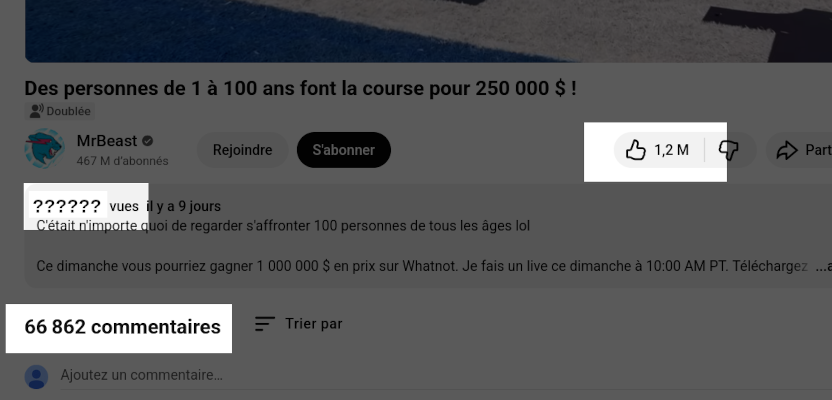

In [17]:
#@title Exercice 2.2 : Avant de commencer, regardez les données

### Jettez un oeil aux données pour savoir ce qu'elles contiennent
display(df_mr_beast)
display(df_mr_beast.describe())

### Affichez deux nuages de points:
### - Le nombre de vues (en y) en fonction du nombre de likes (en x)
### - Le nombre de vues (en y) en fonction du nombre de commentaires (en x)
display(px.scatter(df_mr_beast, y="viewCount", x="likeCount"))
display(px.scatter(df_mr_beast, y="viewCount", x="commentCount"))

,id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,contentDetails.duration,...,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.url,thumbnails.high.width,thumbnails.high.height,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags
0,NaN,NaN,SUBSCRIBE FOR A COOKIE! New MrBeast or MrBeast...,2012-02-20 00:43:50+00:00,NaN,0,NaN,NaN,NaN,NaN,...,NaN,NaN,https://yt3.ggpht.com/nxYrc_1_2f77DoBadyxMTmv7...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2XVcLrB7B3Y,Worst Minecraft Saw Trap Ever???,This is the worst saw trap ever done in minecr...,2012-02-20 22:42:32+00:00,youtube#video,157,30023171.0,1293994.0,132922.0,PT2M37S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,jP82d277Cc8,Harry Potter Mod In Minecraft! EPIC MUST SEE M...,One of the coolest mods i have ever seen Mod: ...,2012-03-09 23:29:03+00:00,youtube#video,239,5872106.0,NaN,9235.0,PT3M59S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Z8nEEdXTaX0,Boxy item mod Minecraft. EPIC,At the begining i said i was mrbeast6000.... i...,2013-01-12 22:34:11+00:00,youtube#video,90,1550590.0,56755.0,4271.0,PT1M30S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Y74b7WlcEpk,More birds IN MINECRAFT!!,Basically what this mod does is adds more bird...,2013-01-12 23:35:45+00:00,youtube#video,126,1321568.0,48249.0,3814.0,PT2M6S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,kNLr-cduzuo,Wait... Was He Famous?,NaN,2026-01-25 20:00:01+00:00,youtube#video,14,87227596.0,2319016.0,22550.0,PT14S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
924,_sBRk9ADpK8,"Flip a Coin, Win $30,000",NaN,2026-01-27 17:00:03+00:00,youtube#video,47,196728839.0,3631320.0,19568.0,PT47S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
925,9WEQts7b8Pw,"Ages 1 - 100 Race For $250,000!",Watching 100 people from every age compete was...,2026-02-07 17:00:01+00:00,youtube#video,1411,54301092.0,1269388.0,65628.0,PT23M31S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
926,gar4U3n-ILY,Guess What Age Punched You,NaN,2026-02-09 17:00:00+00:00,youtube#video,37,125113627.0,2384311.0,17584.0,PT37S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.width,thumbnails.default.height,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.width,thumbnails.high.height,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags
count,928.000000,9.230000e+02,9.160000e+02,922.000000,4.0,4.0,4.0,4.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0
mean,1098.204741,1.053718e+08,2.927750e+06,39028.973970,120.0,90.0,320.0,180.0,480.0,360.0,NaN,NaN,NaN,NaN,NaN
std,6563.647128,1.726853e+08,5.586931e+06,67354.175563,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
min,0.000000,3.595600e+04,8.460000e+02,0.000000,120.0,90.0,320.0,180.0,480.0,360.0,NaN,NaN,NaN,NaN,NaN
25%,119.000000,1.537440e+05,4.302500e+03,582.500000,120.0,90.0,320.0,180.0,480.0,360.0,NaN,NaN,NaN,NaN,NaN
50%,245.500000,2.388282e+07,6.237750e+05,9752.500000,120.0,90.0,320.0,180.0,480.0,360.0,NaN,NaN,NaN,NaN,NaN
75%,759.250000,1.612105e+08,3.498185e+06,55696.500000,120.0,90.0,320.0,180.0,480.0,360.0,NaN,NaN,NaN,NaN,NaN
max,86402.000000,1.639755e+09,5.711583e+07,798700.000000,120.0,90.0,320.0,180.0,480.0,360.0,NaN,NaN,NaN,NaN,NaN


In [18]:
#@title Exercice 2.3 : Nettoyage du jeu de données

# Remplissez ce DataFrame
# On ne sera pas intéressés par toutes les colonnes (d'autant plus que certaines sont vides)
# Gardez seulement trois colonnes: viewCount, likeCount, commentCount
df_mr_beast_nettoye = ...

# Affichez le jeu de données pour vérifier s'il est prêt à être utilisé

# Au besoin, modifiez des choses dedans

#######

df_mr_beast_nettoye = df_mr_beast[['viewCount', 'likeCount', 'commentCount']]

# Après un premier affichage, on va se rendre compte qu'il y a des cases avec des NaN!
# On doit supprimer les lignes avec des données manquantes
display(df_mr_beast_nettoye)

df_mr_beast_nettoye = df_mr_beast_nettoye.dropna()

display(df_mr_beast_nettoye)

,viewCount,likeCount,commentCount
0,NaN,NaN,NaN
1,30023171.0,1293994.0,132922.0
2,5872106.0,NaN,9235.0
3,1550590.0,56755.0,4271.0
4,1321568.0,48249.0,3814.0
...,...,...,...
923,87227596.0,2319016.0,22550.0
924,196728839.0,3631320.0,19568.0
925,54301092.0,1269388.0,65628.0
926,125113627.0,2384311.0,17584.0


,viewCount,likeCount,commentCount
1,30023171.0,1293994.0,132922.0
3,1550590.0,56755.0,4271.0
4,1321568.0,48249.0,3814.0
5,1178150.0,42948.0,3583.0
6,1063037.0,36901.0,3213.0
...,...,...,...
923,87227596.0,2319016.0,22550.0
924,196728839.0,3631320.0,19568.0
925,54301092.0,1269388.0,65628.0
926,125113627.0,2384311.0,17584.0


Une fois les données prêtes : créez un modèle de régression linéaire qui va prédire correctement le nombre de likes sur une vidéo de Mr.Beast, en utilisant la `LinearRegression()` de `sklearn`.

&nbsp;

Vous devez :
- Séparer vos données en entraînement/test (utilisez `train_test_split` avec `random_state=25` et `test_size=0.25`)
- Créer le modèle
- L'entraîner
- Choisir le meilleur modèle en comparant les erreurs RMSE des deux

&nbsp;

**Comparez deux possibilités de modèles** :

1. Prédire le nombre de `views` à partir du nombre de `likes`
2. Prédire le nombre de `views` à partir du nombre de `commentaires`

Pour chacun des deux modèles, affichez :

- L'erreur RMSE sur les données d'entraînement
- L'erreur RMSE sur les données de test

**Vous aurez besoin de réexécuter cette cellule pour chacune des deux possibilités `likes` vs `comments`**

In [19]:
#@title Exercice 2.4 : Régression linéaire sur les views de Mr. Beast

# 1. On sépare les données en entraînement/test
df_entrainement, df_test = train_test_split(df_mr_beast_nettoye, random_state=25, test_size=0.25)

nom_colonne = 'likeCount'
# nom_colonne = 'commentCount' # Décommenter pour tester celle-ci

X_entrainement = df_entrainement[[nom_colonne]]
y_entrainement = df_entrainement['viewCount']

X_test = df_test[[nom_colonne]]
y_test = df_test['viewCount']

# 2. Créer le modèle
modele = LinearRegression()

# 3. Entraîner
modele.fit(X_entrainement, y_entrainement)

# 4. Évaluer
y_predictions_entrainement = modele.predict(X_entrainement)
y_predictions_test = modele.predict(X_test)

print("===", nom_colonne, "===")
print("RMSE (entrainement) avec", nom_colonne, ":", root_mean_squared_error(y_entrainement, y_predictions_entrainement))
print("RMSE (test) avec", nom_colonne, ":", root_mean_squared_error(y_test, y_predictions_test))

=== likeCount ===
RMSE (entrainement) avec likeCount : 72069347.63688974
RMSE (test) avec likeCount : 78923688.25563353


Une fois que c'est fait, exécutez la cellule suivante pour regarder le résultat :

In [20]:
#@title Visualisation de la droite apprise
from ipywidgets import interact
import plotly.graph_objects as go

def dessiner_views_avec_droite(modele):
  caracteristique = modele.feature_names_in_[0]
  valeurs_x = np.linspace(0, df_mr_beast[caracteristique].max(), 3000)
  valeurs_y = modele.predict(pd.DataFrame({
      caracteristique: valeurs_x
  }))
  df = pd.DataFrame({"x": valeurs_x, "y": valeurs_y})
  plot = px.scatter(df_mr_beast, x=caracteristique, y="viewCount")
  ligne = px.line(df, x="x", y="y", color_discrete_sequence=['red'])
  fig = go.FigureWidget(data=plot.data + ligne.data)
  fig.update_layout(
      title="Droite apprise",
      xaxis=dict(title=caracteristique),
      yaxis=dict(title="viewCount"),
      )
  display(fig.show())

dessiner_views_avec_droite(modele)

None

**Réexécutez la dernière cellule après avoir testé chaque méthode pour voir le résultat**

**QUESTION 2.5**

Notez les erreurs RMSE d'entraînement et de test pour les deux modèles dans la prochaine cellule.

In [21]:
#@title Exercice 2.5

df_erreurs = pd.DataFrame([
    ["RMSE entrainement", "comments", 30.0],
    ["RMSE test", "comments",         20.0],
    ["RMSE entrainement", "likes",    50.0],
    ["RMSE test", "likes",            40.0],
], columns=['type', 'variable', 'erreur'])

#############

df_erreurs = pd.DataFrame([
    ["RMSE entrainement", "comments", 155512523.0071754],
    ["RMSE test", "comments",         166059126.57450733],
    ["RMSE entrainement", "likes",    72069347.63688974],
    ["RMSE test", "likes",            78923688.25563353],
], columns=['type', 'variable', 'erreur'])

###### tests

px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')

**QUESTION 2.6**

Quel modèle choisiriez-vous parmi ces deux?

**RÉPONSE**

likeCount a une erreur RMSE significativement plus petite, ce qui veut dire qu'il estime mieux le nombre de views que l'autre

## Erreur d'entraînement vs erreur de test

Notez la chose suivante dans votre graphique ci-haut : **l'erreur de test est plus élevée que l'erreur d'entraînement**.

Autrement dit : la droite apprise est meilleure pour estimer les données utilisées pour l'entraînement que pour prédire des nouvelles données.

&nbsp;

Ça nous rappelle bien l'importance de séparer les données pour avoir un estimé correct de l'erreur commise par le modèle. Si on essayait d'estimer la qualité du modèle directement sur l'ensemble d'entraînement, on surestimerait sa qualité ici.

## Comparaison de notre modèle avec un algorithme simpliste (*baseline*)

En elle-même, l'erreur RMSE est difficile à interpréter.

&nbsp;

Comme pour l'exemple avec KNN dans le dernier module, on peut cependant comparer notre modèle avec des méthodes stupides :

1. Dire toujours la moyenne du nombre de views
2. Dire toujours la médiane du nombre de views

Puisque l'idée d'un modèle stupide est commune, `sklearn` fournit aussi du code qui fait pile ça :

```
   from sklearn.dummy import DummyRegressor
   modele_moyenne = DummyRegressor(strategy='mean')
   modele_mediane = DummyRegressor(strategy='median')
```

&nbsp;

On va refaire tout le processus d'entraînement et d'évaluation, mais avec ces deux "modèles" pour voir de quoi aurait l'air l'erreur RMSE d'une stratégie stupide.

Pour se faciliter la vie et éviter de copier-coller le même code plusieurs fois, on va se faire une *fonction* qui refait ces étapes avec un modèle et des données différents :

In [22]:
#@title Fonction qui crée et entraîne un modèle

def entrainer_et_evaluer(modele, df, colonne_a_predire):
  # 1. On sépare les données en entraînement/test
  df_entrainement, df_test = train_test_split(df, random_state=25, test_size=0.25)

  # X = tout sauf la colonne_a_predire
  X_entrainement = df_entrainement.drop(colonne_a_predire, axis='columns')
  # y = seulement la colonne_a_predire
  y_entrainement = df_entrainement[colonne_a_predire]

  X_test = df_test.drop(colonne_a_predire, axis='columns')
  y_test = df_test[colonne_a_predire]

  # 2. Le modèle doit déjà avoir été créé et passé en paramètre à la fonction
  # modele = LinearRegression()

  # 3. Entraîner
  modele.fit(X_entrainement, y_entrainement)

  y_predictions_entrainement = modele.predict(X_entrainement)
  y_predictions_test = modele.predict(X_test)

  rmse_entrainement = root_mean_squared_error(y_entrainement, y_predictions_entrainement)
  rmse_test = root_mean_squared_error(y_test, y_predictions_test)

  # On retourne les erreurs RMSE d'entraînement et de test pour les évaluer
  return [rmse_entrainement, rmse_test]

**QUESTION 5.5**

Complétez le code suivant qui utilise la fonction pour évaluer différents modèles, puis complétez le tableau à la cellule suivante

In [23]:
#@title Exercice 2.7
from sklearn.dummy import DummyRegressor

df_commentaires = df_mr_beast_nettoye[['viewCount', 'commentCount']]

modele_regression_commentaires = LinearRegression()
rmse_entrainement_commentaires, rmse_test_commentaires = entrainer_et_evaluer(modele_regression_commentaires, df_commentaires, 'viewCount')
print("== Régression linéaire sur les commentaires ==")
print("RMSE (entrainement):", rmse_entrainement_commentaires)
print("RMSE (test):", rmse_test_commentaires)
print()

modele_moyenne = DummyRegressor(strategy='mean')
rmse_entrainement_moyenne, rmse_test_moyenne = entrainer_et_evaluer(modele_moyenne, df_commentaires, 'viewCount')
print("== Méthode stupide 1: toujours dire la moyenne des views ==")
print("RMSE (entrainement):", rmse_entrainement_moyenne)
print("RMSE (test):", rmse_test_moyenne)
print()

# TODO : Utilisez la méthode avec une régression linéaire sur les likes plutôt
# que les commentaires avec la méthode entrainer_et_evaluer()
# (ça devrait vous redonner les mêmes RMSE que plus haut)
modele_regression_likes = ...
rmse_entrainement_likes, rmse_test_likes = 0.0, 0.0 # TODO: Changez ça
print("== Régression linéaire sur les likes ==")
print("RMSE (entrainement):", rmse_entrainement_likes)
print("RMSE (test):", rmse_test_likes)

# TODO: ajoutez la stratégie median
modele_mediane = ...
rmse_entrainement_mediane, rmse_test_mediane = 0.0, 0.0 # TODO: Changez ça


##################

print("======================")

df_likes = df_mr_beast_nettoye[['viewCount', 'likeCount']]


modele_regression_likes = LinearRegression()
rmse_entrainement_likes, rmse_test_likes = entrainer_et_evaluer(modele_regression_commentaires, df_likes, 'viewCount')
print("== Régression linéaire sur les likes ==")
print("RMSE (entrainement):", rmse_entrainement_likes)
print("RMSE (test):", rmse_test_likes)
print()

modele_mediane = DummyRegressor(strategy='median')
rmse_entrainement_mediane, rmse_test_mediane = entrainer_et_evaluer(modele_mediane, df_commentaires, 'viewCount')
print("== Méthode stupide 2: toujours dire la médiane des views ==")
print("RMSE (entrainement):", rmse_entrainement_mediane)
print("RMSE (test):", rmse_test_mediane)
print()

###### tests

df_erreurs = pd.DataFrame([
    ["RMSE entrainement", "moyenne",    rmse_entrainement_moyenne],
    ["RMSE test", "moyenne",            rmse_test_moyenne],
    ["RMSE entrainement", "médiane",    rmse_entrainement_mediane],
    ["RMSE test", "médiane",            rmse_test_mediane],
    ["RMSE entrainement", "comments", rmse_entrainement_commentaires],
    ["RMSE test", "comments",         rmse_test_commentaires],
    ["RMSE entrainement", "likes",    rmse_entrainement_likes],
    ["RMSE test", "likes",            rmse_test_likes],
], columns=['type', 'variable', 'erreur'])


px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')

== Régression linéaire sur les commentaires ==
RMSE (entrainement): 155512523.0071754
RMSE (test): 166059126.57450733

== Méthode stupide 1: toujours dire la moyenne des views ==
RMSE (entrainement): 173679199.9725637
RMSE (test): 171331992.15606025

== Régression linéaire sur les likes ==
RMSE (entrainement): 0.0
RMSE (test): 0.0
== Régression linéaire sur les likes ==
RMSE (entrainement): 72069347.63688974
RMSE (test): 78923688.25563353

== Méthode stupide 2: toujours dire la médiane des views ==
RMSE (entrainement): 192136092.6042148
RMSE (test): 189253847.1924013



Vous devriez voir la chose suivante :

L'erreur RMSE avec la moyenne seulement est légèrement plus haute que l'erreur RMSE pour les commentaires.

Le nombre de commentaires n'apporte donc pas beaucoup d'information sur le nombre de views

## *Complément : lien avec vos autres cours de sciences*

La régression linéaire est utilisée en apprentissage machine, mais il s'agit d'une méthode utilisée dans beaucoup de domaines.

&nbsp;

### Dans les sciences expérimentales en général

Le **Guide méthodologique pour les sciences expérimentales** du collège de Bois-de-Boulogne décrit l'étude d'une courbe de tendance et d'une droite de régression dans la section 5.2 - Éléments de base des graphiques.

### En statistiques

La façon traditionnelle d'évaluer une régression est de regarder **le coefficient de détermination $R^2$**. C'est d'ailleurs le score utilisé par défaut dans `sklearn`.

La façon de calculer ce score compare directement la somme des résidus au carrés avec l'erreur qu'on aurait eue en utilisant toujours la moyenne comme prédicteur.

J'ai préféré utiliser directement l'erreur RMSE, entre autres :

- Parce que la formule est un peu plus simple
- Parce qu'on va revoir quelque chose de similaire à l'erreur RMSE dans le contexte des réseaux de neurones

# En résumé

- Une **régression** consiste à prédire des valeurs numériques ou ordonnées
- On peut utiliser KNN pour faire de la régression
- KNN a un gros défaut : il ne généralise pas
- En apprentissage, on veut **généraliser** et arriver à prédire des choses pour des données différentes de ce qu'on connaît déjà
- La **régression linéaire** consiste à trouver une droite qui passe le mieux possible dans notre ensemble de points
- On appelle des **paramètres** les valeurs apprises par un algorithme
- On peut évaluer l'erreur d'une régression avec **l'erreur RMSE**
- Comme pour la classification, c'est important de comparer cette erreur avec une *baseline* (ex.: comparer à toujours dire la moyenne/la médiane)
